# Different Model Settings

The SPyIce package is a software tool that enables 1D finite difference simulation for vertical transport equations. It specifically focuses on thermal diffusion with the influence of salinity and physical properties. The package utilizes the Thomas tridiagonal solver as the solver algorithm. With SPyIce, users can model and analyze the behavior of temperature, salinity, and other relevant variables in a vertical system. It provides a comprehensive framework for studying the thermal diffusion process and its interaction with salinity in various scenarios. Hydra is used to automate the simulation runs of the Sea-Ice Model. It is used to manage and run sea ice simulations, making it easier for users to explore different scenarios and optimize their models.

#### Import Packages

In [14]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

In [23]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "iter_max": {"iter_max": 10000},
    "dz": {"dz": 0.05},
    "model": {"is_diffusiononly_equation": False, "is_salinity_equation": True, "is_radiation_equation": True, "is_algae_equation": True, "algae_model_BAL_type": "all"},
    "ICBC": {"S_IC": 'S_34', "T_BC": 265.0}
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, "S", "2", "0.01", "47", "1000", "example")

### Preprocessing

In [3]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.


#### Model settings

for more info on all the model parameters have a look at the documentation: [userinput](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.parameters.user_input.html)

In [4]:
from spyice.parameters.user_input import Constants

# Choose between real and test constants
constants = Constants.REAL.value

##### Model settings: Model type choose between ->
- Algae model 
- Algae model type : Multiple layers or Single layer 
- Radiation model
- Only diffusion model (without advection)
- Salinity Model

In [5]:
# change user input data
userinput_data.is_diffusiononly_equation = True
userinput_data.is_algae_equation = False
userinput_data.is_radiation_equation = False
userinput_data.is_salinity_equation = False
userinput_data.algae_model_BAL_type = "all"   # or "all" or "single"

##### Model settings: Initial Conditions

In [6]:
    # --- Initial Conditions ---
from spyice.parameters.user_input import InitialTemperature, InitialSalinity, InitialLiquidFraction

userinput_data.initial_temperature = InitialTemperature.T_S.value
userinput_data.initial_salinity = InitialSalinity.S34.value
userinput_data.initial_liquid_fraction = InitialLiquidFraction.P1.value


##### Model settings: Boundary conditions

In [7]:
from spyice.parameters.user_input import BoundaryConditionType
from spyice.parameters.user_input import TopTemperatureType

userinput_data.boundary_condition_type = BoundaryConditionType.DIRICHLET.value
userinput_data.temperature_top_type = TopTemperatureType.STEFAN.value
userinput_data.boundary_top_temperature = 265

##### Model settings: Phase relation

In [8]:
from spyice.parameters.user_input import LiquidusRelation

userinput_data.liquidus_relation_type = LiquidusRelation.NORMAL.value

##### Update Preprocess Data

In [9]:
preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)

Time step set to: 47s
Updated Initial & Boundary Conditions...


### Run model

In [10]:
# run the model
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )

Model run complete and Ready for Analysis.
Residuals exported successfully.


### Visualization of Model:
for more info on other visualization options look at:  [visualize model](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.postprocess.visualise_model.html)

In [11]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


Plotting Depth over time...


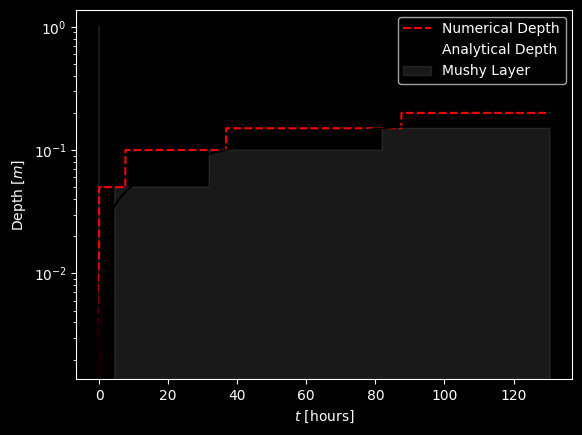

In [12]:
# Plots the interface tracking over time for Analytical and Numerical Solutions
model_visualization_object.plot_depth_over_time(savefig=False, show=True)


Plotting Temperature heatmap...


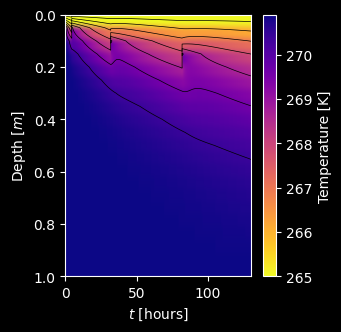

In [13]:
model_visualization_object.plot_temperature_heatmap(savefig=False, show=True)

## Comparing sea ice model for different temperatures

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting Temperature heatmap...
Plotting Salinity heatmap...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting Temperature heatmap...
Plotting Salinity heatmap...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time

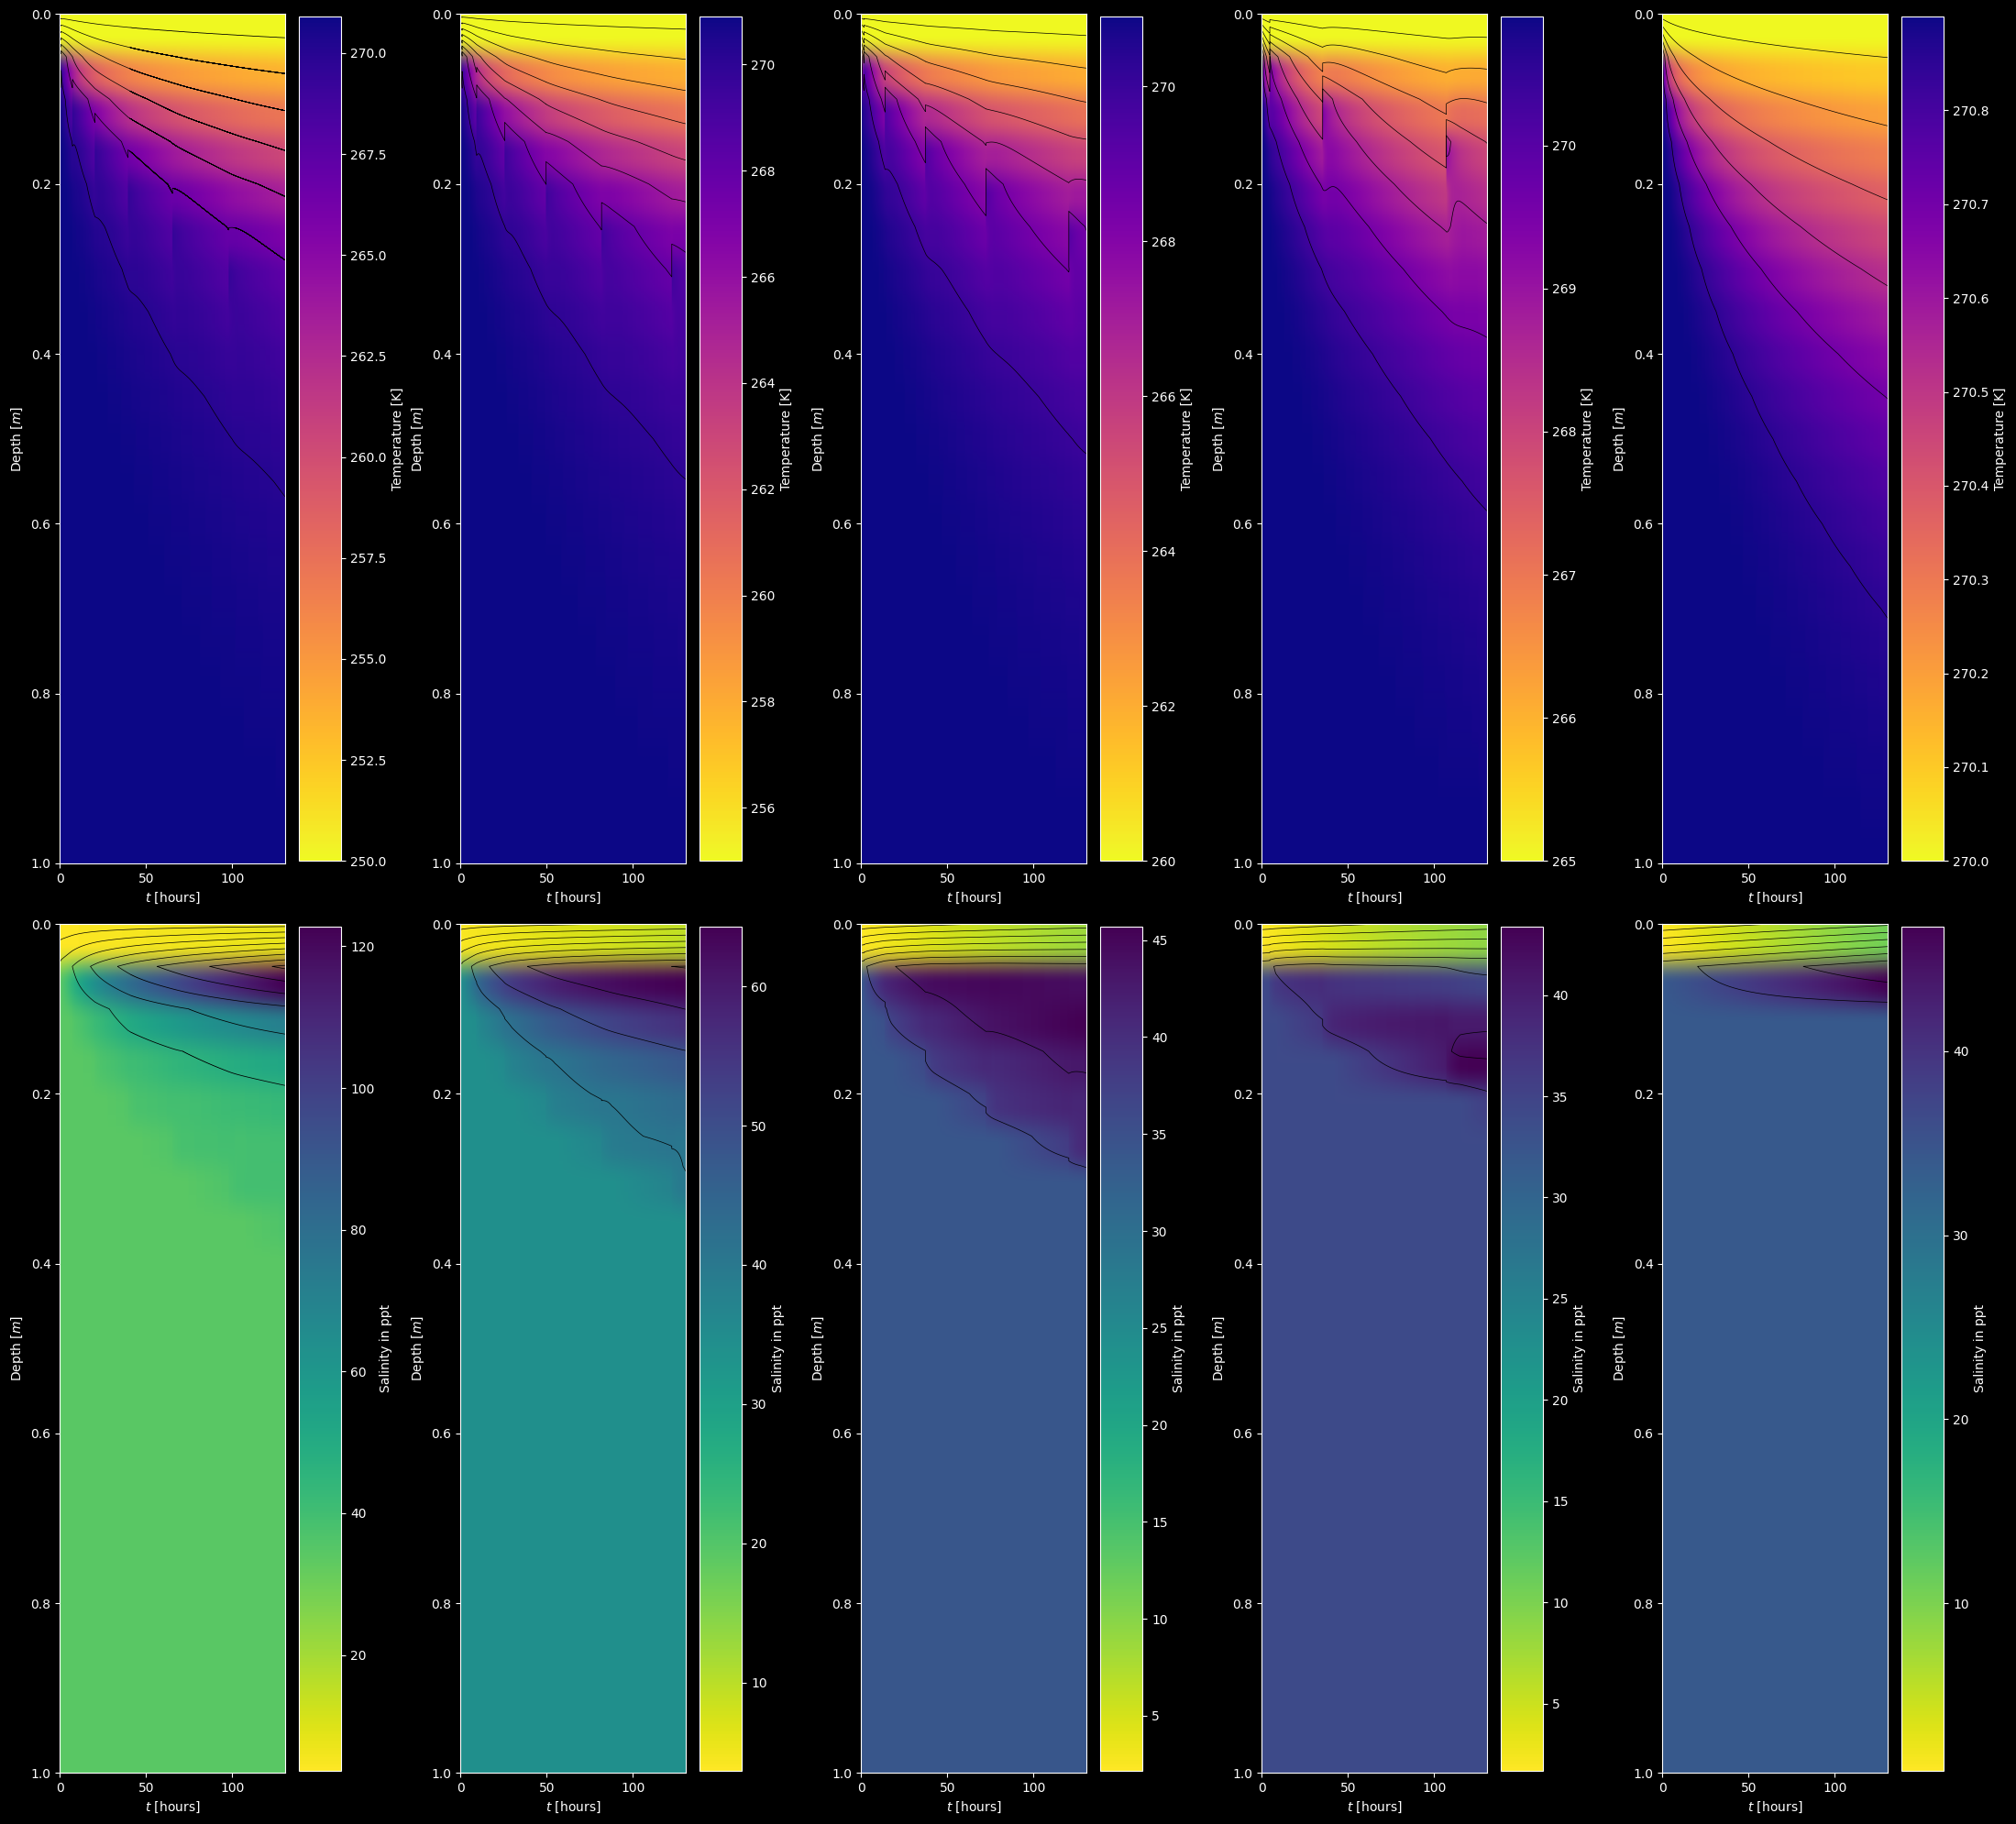

In [22]:
boundary_temperatures = [250.0, 255.0, 260.0, 265.0, 270.0]

fig, ax = plt.subplots(2, 5, figsize=(22,20))

for i, temp_bc in enumerate(boundary_temperatures):
    preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)
    userinput_data.boundary_top_temperature = temp_bc
    preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)
    results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
    analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )
    model_visualization_object = VisualiseModel(
            user_input_dataclass=userinput_data,
            results_dataclass=results_data,
            error_analysis_dataclass=analysis_data
        )
    model_visualization_object.plot_temperature_heatmap(savefig=False, show=False, ax=ax[0,i], fig=fig)
    model_visualization_object.plot_salinity_heatmap(savefig=False, show=False, ax=ax[1,i], fig=fig)

plt.tight_layout()
plt.show()


#### Effect of temperature on microalgae growth

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting nutrient concentration of all layers: heatmap...
Plotting carbon concentration multiple layers...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting nutrient concentration of all layers: heatmap...
Plotting carbon concentration multiple layers...
Preprocessing...
User Configuratio

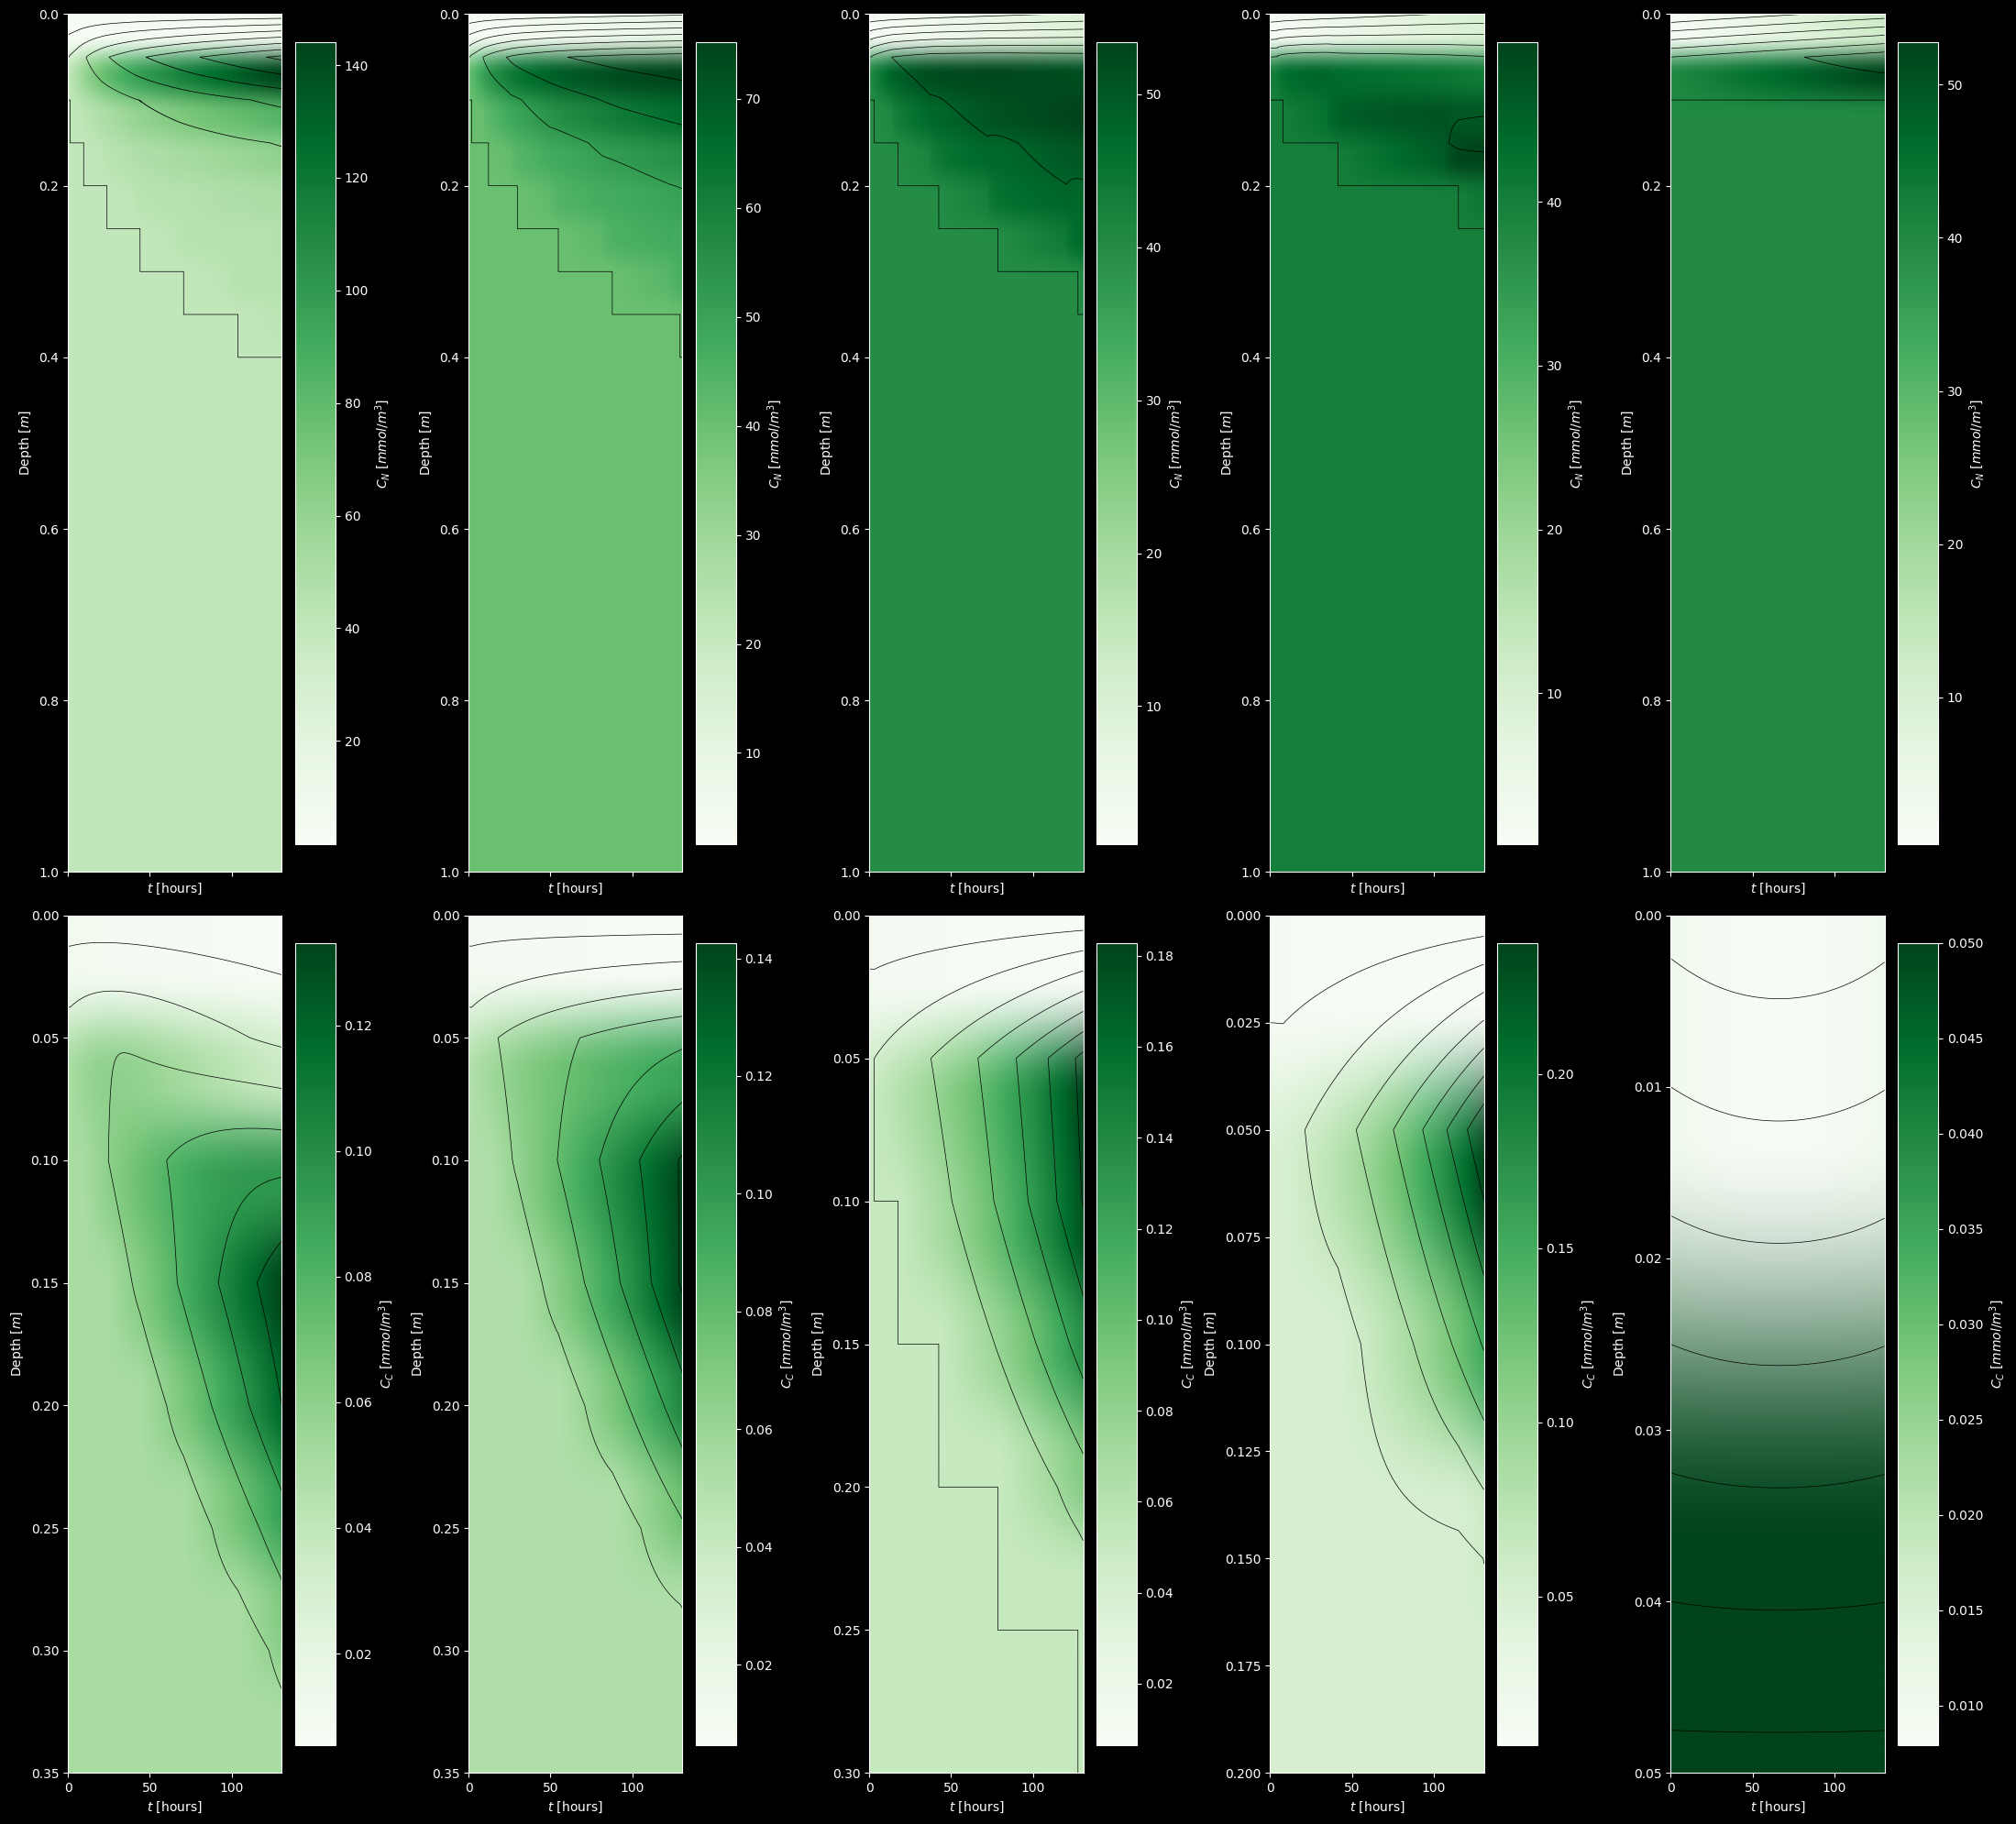

In [25]:
boundary_temperatures = [250.0, 255.0, 260.0, 265.0, 270.0]

fig, ax = plt.subplots(2, 5, figsize=(22,20), sharex=True)

for i, temp_bc in enumerate(boundary_temperatures):
    preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)
    userinput_data.boundary_top_temperature = temp_bc
    preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)
    results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
    analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )
    model_visualization_object = VisualiseModel(
            user_input_dataclass=userinput_data,
            results_dataclass=results_data,
            error_analysis_dataclass=analysis_data
        )
    model_visualization_object.plot_nutrient_concentration_multiplelayers(savefig=False, show=False, ax=ax[0,i], fig=fig)
    model_visualization_object.plot_carbon_concentration_multiplelayers(savefig=False, show=False, ax=ax[1,i], fig=fig)

plt.tight_layout()
plt.show()


Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 100s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 100s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting nutrient concentration of all layers: heatmap...
Plotting carbon concentration multiple layers...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 100s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 100s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting nutrient concentration of all layers: heatmap...
Plotting carbon concentration multiple layers...
Preprocessing...
User Configur

ValueError: zero-size array to reduction operation minimum which has no identity

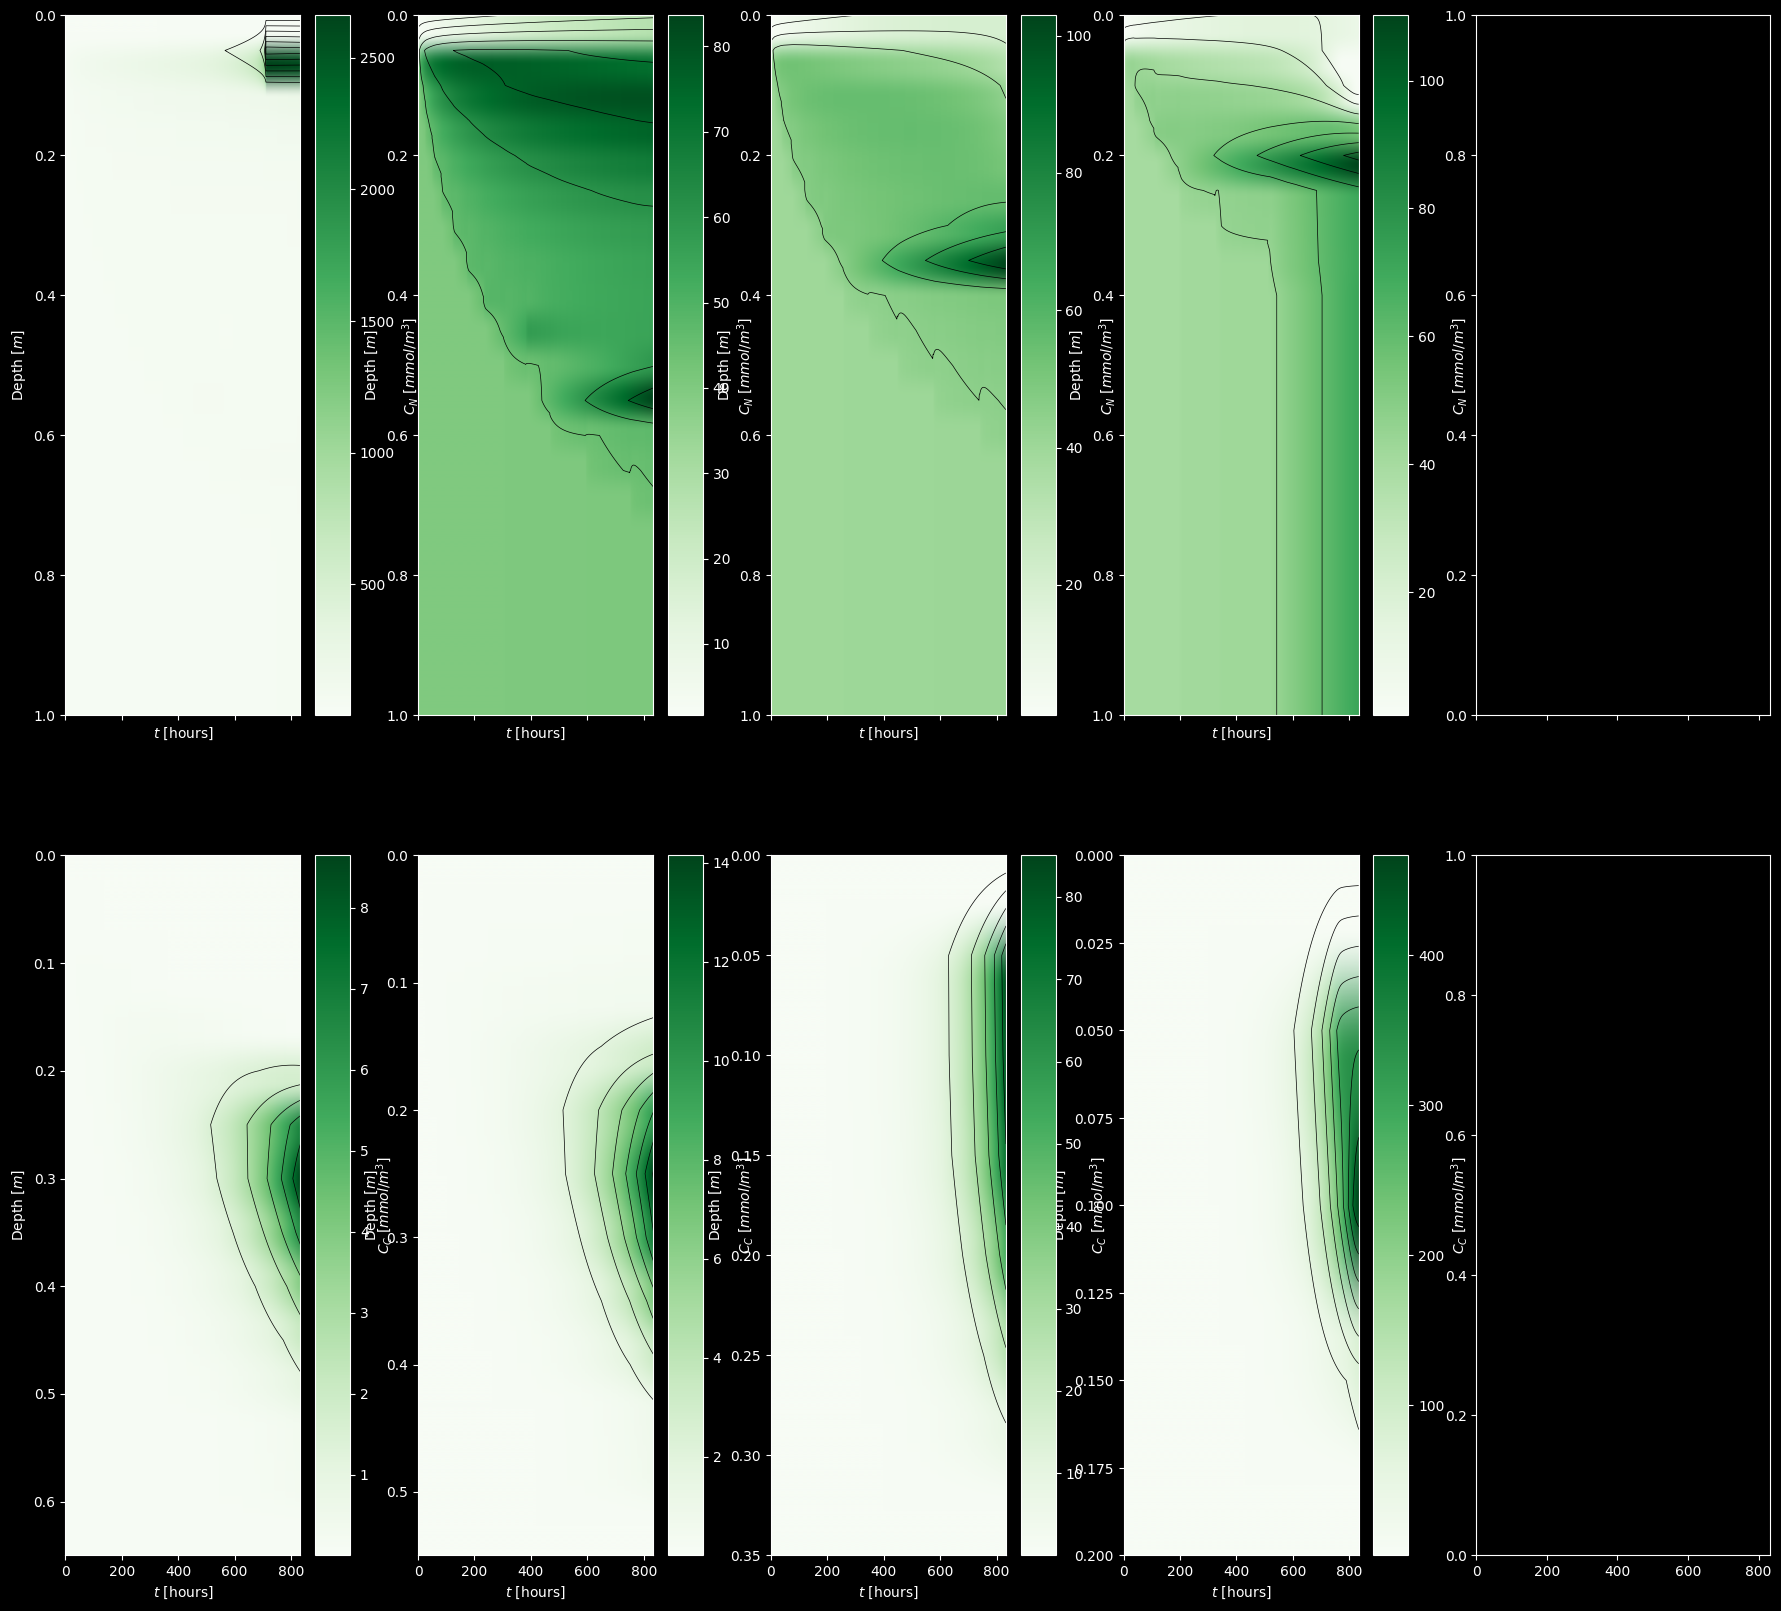

In [26]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 100},
    "iter_max": {"iter_max": 30000},
    "dz": {"dz": 0.05},
    "model": {"is_diffusiononly_equation": False, "is_salinity_equation": True, "is_radiation_equation": True, "is_algae_equation": True, "algae_model_BAL_type": "all"},
    "ICBC": {"S_IC": 'S_34', "T_BC": 265.0}
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, "S", "2", "0.01", "47", "1000", "example")

boundary_temperatures = [250.0, 255.0, 260.0, 265.0, 270.0]

fig, ax = plt.subplots(2, 5, figsize=(22,20), sharex=True)

for i, temp_bc in enumerate(boundary_temperatures):
    preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)
    userinput_data.boundary_top_temperature = temp_bc
    preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)
    results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
    analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )
    model_visualization_object = VisualiseModel(
            user_input_dataclass=userinput_data,
            results_dataclass=results_data,
            error_analysis_dataclass=analysis_data
        )
    model_visualization_object.plot_nutrient_concentration_multiplelayers(savefig=False, show=False, ax=ax[0,i], fig=fig)
    model_visualization_object.plot_carbon_concentration_multiplelayers(savefig=False, show=False, ax=ax[1,i], fig=fig)

plt.tight_layout()
plt.show()


## Comparing sea ice model for different salinity

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting Salinity heatmap...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Time step set to: 47s
Updated Initial & Boundary Conditions...
Model run complete and Ready for Analysis.
Residuals exported successfully.
Visualisation object created...
Plotting Salinity heatmap...
Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Prepr

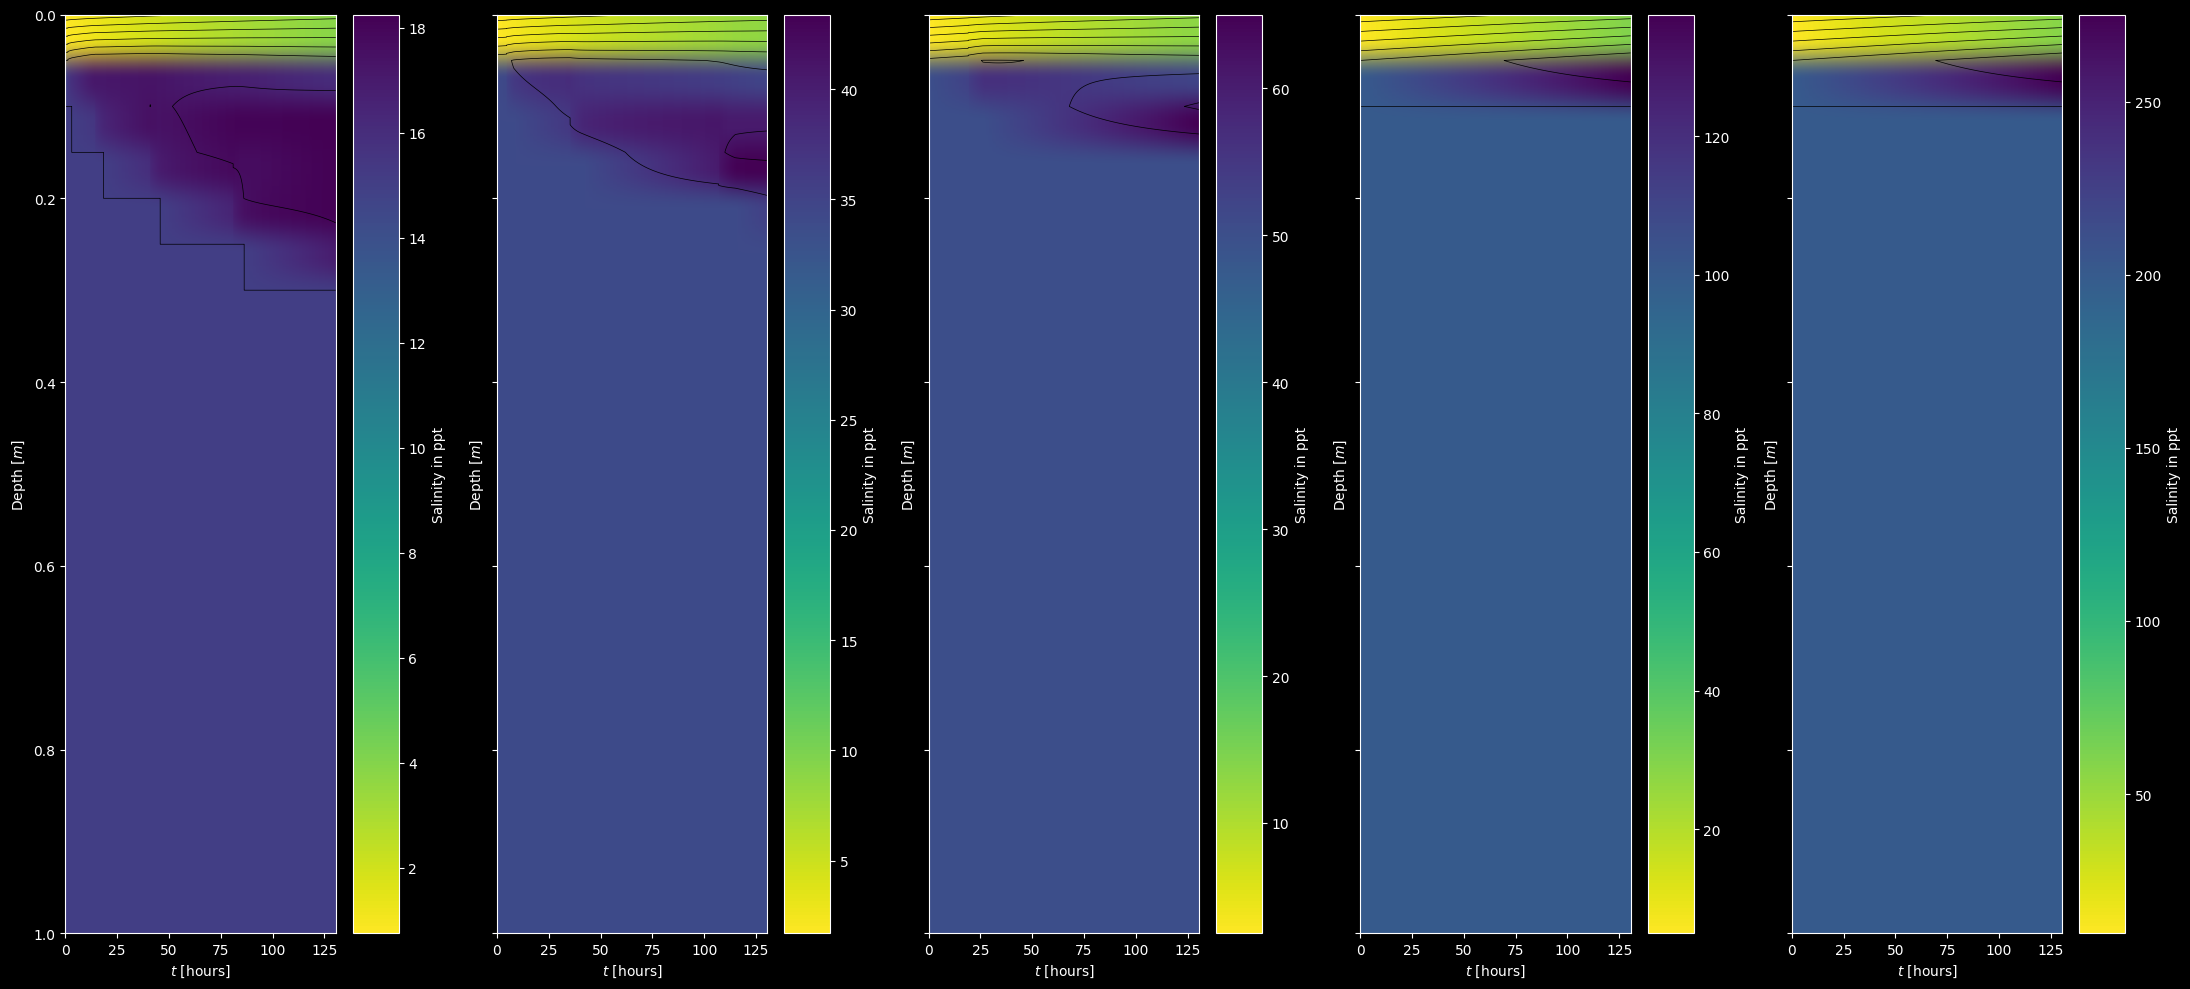

In [20]:
initial_salinity = ["S15", "S34", "S50", "S100", "S200"]
boundary_salinity = [15, 34, 50, 100, 200]
fig, ax = plt.subplots(1, 5, sharey=True, figsize=(22,10))

for i, salt_ic in enumerate(initial_salinity):
    preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)
    userinput_data.initial_salinity = salt_ic
    userinput_data.boundary_salinity = boundary_salinity[i]
    preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)
    results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
    analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )
    model_visualization_object = VisualiseModel(
            user_input_dataclass=userinput_data,
            results_dataclass=results_data,
            error_analysis_dataclass=analysis_data
        )
    model_visualization_object.plot_salinity_heatmap(savefig=False, show=False, ax=ax[i], fig=fig)

plt.tight_layout()
plt.show()
